In [4]:
import pandas as pd

data = pd.read_csv('bankmarket.csv', sep=';')
data

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [5]:
features = ['age', 'duration', 'campaign', 'previous', 'housing', 'loan']
X = data[features].copy()
y = data['y']

X['housing'] = X['housing'].map({'yes': 1, 'no': 0, 'unknown': -1})
X['loan']    = X['loan'].map({'yes': 1, 'no': 0, 'unknown': -1})
X

,age,duration,campaign,previous,housing,loan
0,56,261,1,0,0,0
1,57,149,1,0,0,0
2,37,226,1,0,1,0
3,40,151,1,0,0,0
4,56,307,1,0,0,1
...,...,...,...,...,...,...
41183,73,334,1,0,1,0
41184,46,383,1,0,0,0
41185,56,189,2,0,1,0
41186,44,442,1,0,0,0


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test     = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f'Train : {X_train.shape[0]}')
print(f'Val   : {X_val.shape[0]}')
print(f'Test  : {X_test.shape[0]}')

Train : 28831
Val   : 6178
Test  : 6179


In [7]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

rf_val_acc  = rf.score(X_val, y_val)
rf_test_acc = rf.score(X_test, y_test)

print(f'Random Forest - Validation Accuracy : {rf_val_acc:.4f}')
print(f'Random Forest - Test Accuracy       : {rf_test_acc:.4f}')

Random Forest - Validation Accuracy : 0.8851
Random Forest - Test Accuracy       : 0.8854


In [8]:
from sklearn.ensemble import AdaBoostClassifier

ab = AdaBoostClassifier(random_state=42)
ab.fit(X_train, y_train)

ab_val_acc  = ab.score(X_val, y_val)
ab_test_acc = ab.score(X_test, y_test)

print(f'AdaBoost - Validation Accuracy : {ab_val_acc:.4f}')
print(f'AdaBoost - Test Accuracy       : {ab_test_acc:.4f}')

AdaBoost - Validation Accuracy : 0.8935
AdaBoost - Test Accuracy       : 0.8937


In [9]:
from sklearn.metrics import classification_report, confusion_matrix

print('=== Random Forest ===')
print(classification_report(y_test, rf.predict(X_test)))

print('=== AdaBoost ===')
print(classification_report(y_test, ab.predict(X_test)))

=== Random Forest ===
              precision    recall  f1-score   support

          no       0.92      0.95      0.94      5488
         yes       0.48      0.34      0.40       691

    accuracy                           0.89      6179
   macro avg       0.70      0.65      0.67      6179
weighted avg       0.87      0.89      0.88      6179

=== AdaBoost ===
              precision    recall  f1-score   support

          no       0.90      0.98      0.94      5488
         yes       0.58      0.17      0.27       691

    accuracy                           0.89      6179
   macro avg       0.74      0.58      0.61      6179
weighted avg       0.87      0.89      0.87      6179



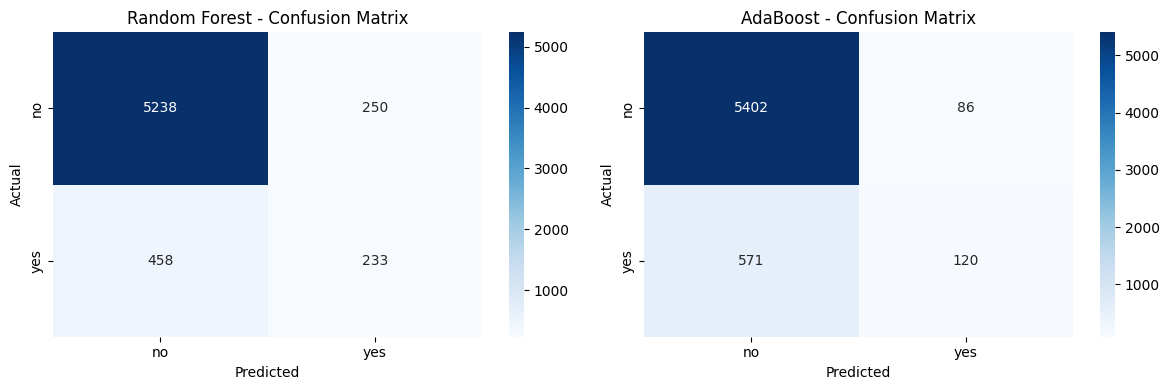

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, model, name in zip(axes,
                            [rf, ab],
                            ['Random Forest', 'AdaBoost']):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=['no','yes'], yticklabels=['no','yes'])
    ax.set_title(f'{name} - Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

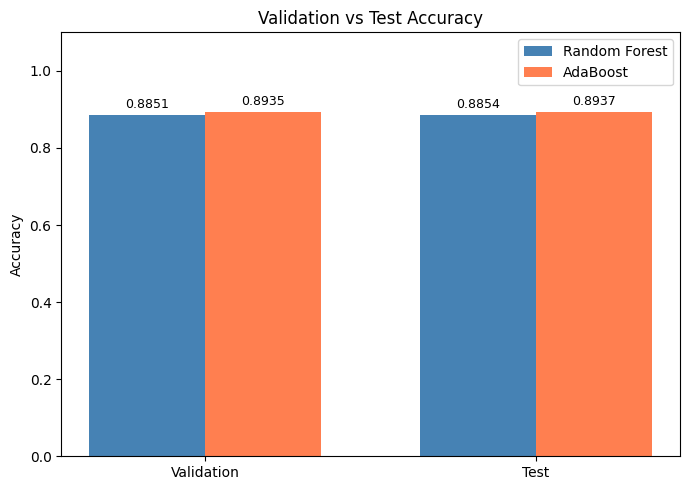

In [11]:
labels  = ['Validation', 'Test']
rf_scores = [rf_val_acc, rf_test_acc]
ab_scores = [ab_val_acc, ab_test_acc]

x = range(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
b1 = ax.bar([i - width/2 for i in x], rf_scores, width, label='Random Forest', color='steelblue')
b2 = ax.bar([i + width/2 for i in x], ab_scores, width, label='AdaBoost',      color='coral')

ax.set_ylim(0, 1.1)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Accuracy')
ax.set_title('Validation vs Test Accuracy')
ax.legend()

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()